# Optical Neural Network (ONN) on MNIST — Phase-Mask Classifier

Notebook version of `scripts/onn_mnist_example.py`.  We train a small **diffractive optical
neural network** (ONN) to classify MNIST digits using a stack of phase masks and free-space
propagation layers.

The final optical field is measured by a bank of 10 detector regions, and the integrated
intensities serve as class logits.  Training is end-to-end with JAX autodiff and Adam.

### Outline

1. **Imports** for JAX, Optax, and `fouriax.optics`.
2. **Paths** for MNIST caching and output artifacts.
3. **Data/model helpers** (MNIST loader, detector bank, ONN builder).
4. **Training configuration** and model hyperparameters.
5. **Build optical pipeline + load/resize MNIST**.
6. **Initialize trainable parameters and differentiable losses**.
7. **Train the ONN** and report accuracy.
8. **Visualize field evolution** for one test sample.


## 1  Imports

We use JAX for differentiable array programming, Optax for optimization, and
`fouriax.optics` to build the diffractive optical stack (`PhaseMask` + propagation +
detector sensor).  `recommend_nyquist_grid` is used to expand the working grid so
propagation sampling remains well-behaved.


In [9]:
from __future__ import annotations

import time
import urllib.request
from pathlib import Path

import jax
import jax.image
import jax.numpy as jnp
import numpy as np
import optax

from fouriax.optics import (
    Field,
    Grid,
    IntensitySensor,
    OpticalLayer,
    OpticalModule,
    PhaseMask,
    Spectrum,
    plan_propagation,
    plot_field_evolution,
    recommend_nyquist_grid,
)

%matplotlib inline

## 2  Repository Root and Artifact Paths

The notebook resolves the repository root dynamically and stores outputs in `artifacts/`.
It also defines a local cache path for MNIST (`artifacts/data/mnist.npz`) to avoid repeated
downloads across runs.


In [10]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing scripts/ and src/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
MNIST_CACHE_PATH = ARTIFACTS_DIR / "data" / "mnist.npz"
FIELD_EVOLUTION_PATH = ARTIFACTS_DIR / "onn_mnist_field_evolution.png"

print(f"REPO_ROOT={REPO_ROOT}")
print(f"MNIST_CACHE_PATH={MNIST_CACHE_PATH}")


REPO_ROOT=/Users/liam/fouriax
MNIST_CACHE_PATH=/Users/liam/fouriax/artifacts/data/mnist.npz


## 3  Data and Model Helper Functions

This section provides three important building blocks:

- `load_mnist(...)`: downloads and caches the dataset, then returns normalized images.
- `build_detector_bank(...)`: creates 10 non-overlapping detector masks on the sensor plane.
- `build_onn_module(...)`: assembles the diffractive stack from trainable phase masks.

### Optical classifier readout (detector logits)

Let $I_L(x,y)$ denote the final-plane intensity after the last optical layer.  For detector
mask $D_k(x,y)$ (class `k`), the measured detector response is

$$
z_k = \sum_{x,y} D_k(x,y)\, I_L(x,y), \qquad k=0,\dots,9.
$$

The vector $z = [z_0, \ldots, z_9]$ is used as the model's class logits.


In [11]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_mnist(cache_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if not cache_path.exists():
        print(f"Downloading MNIST to {cache_path} ...")
        urllib.request.urlretrieve(MNIST_URL, cache_path)

    with np.load(cache_path) as data:
        x_train = data["x_train"].astype(np.float32) / 255.0
        y_train = data["y_train"].astype(np.int32)
        x_test = data["x_test"].astype(np.float32) / 255.0
        y_test = data["y_test"].astype(np.int32)
    return x_train, y_train, x_test, y_test


def build_detector_bank(grid: Grid) -> jnp.ndarray:
    """
    Build 10 non-overlapping detector regions (2 rows x 5 cols) over the sensor plane.
    Returns shape (10, ny, nx).
    """
    x_edges = np.linspace(0, grid.nx, 6, dtype=int)
    y_edges = np.linspace(0, grid.ny, 3, dtype=int)
    masks = np.zeros((10, grid.ny, grid.nx), dtype=np.float32)

    idx = 0
    for row in range(2):
        for col in range(5):
            x0, x1 = x_edges[col], x_edges[col + 1]
            y0, y1 = y_edges[row], y_edges[row + 1]
            masks[idx, y0:y1, x0:x1] = 1.0
            idx += 1
    return jnp.asarray(masks)


def resize_images_to_grid(images: np.ndarray, grid: Grid) -> np.ndarray:
    arr = jnp.asarray(images, dtype=jnp.float32)[..., None]
    resized = jax.image.resize(
        arr,
        shape=(arr.shape[0], grid.ny, grid.nx, 1),
        method="linear",
    )[..., 0]
    return np.asarray(resized, dtype=np.float32)


def build_onn_module(
    params_mask: jnp.ndarray,
    work_grid: Grid,
    propagator: OpticalLayer,
    detector_sensor: IntensitySensor,
) -> OpticalModule:
    layers = []
    for i in range(params_mask.shape[0]):
        upsampled_latent = jax.image.resize(
            params_mask[i],
            shape=(work_grid.ny, work_grid.nx),
            method="linear",
        )
        bounded_phase = 2.0 * jnp.pi * jax.nn.sigmoid(upsampled_latent)
        layers.append(PhaseMask(phase_map_rad=bounded_phase))
        layers.append(propagator)
    module = OpticalModule(layers=tuple(layers), sensor=detector_sensor)
    return module


## 4  Training Configuration

We choose the device backend, optimization hyperparameters, number of diffractive phase
layers, propagation distance, and a reduced subset of MNIST for a fast example run.

Two parameters strongly affect model capacity and cost:

- `num_phase_layers`: depth of the diffractive optical network.
- `phase_mask_downsample`: latent resolution of each trainable phase mask before upsampling
  to the working grid.


In [12]:
device_name = "cpu"  # Change to "gpu" if available.

epochs = 10
batch_size = 64
learning_rate = 0.2
num_phase_layers = 4
phase_mask_downsample = 4
nyquist_factor = 1.0
distance_um = 50.0
train_samples = 1000
test_samples = 100
seed = 0


## 5  Build Optical Pipeline and Load MNIST

### Working grid and propagation planning

MNIST images start on a `28x28` input grid, but the notebook uses
`recommend_nyquist_grid(...)` to construct a larger `work_grid` for numerically stable
propagation.  This is analogous to the sampling-aware setup used in other examples.

### Diffractive ONN architecture

For each phase layer $\ell$, the notebook upsamples a latent parameter map and bounds it as

$$
\phi_\ell(x,y) = 2\pi\,\sigma\big(r_\ell^{\uparrow}(x,y)\big),
$$

then applies a phase mask and propagation stage.  Repeating this yields a cascaded optical
module whose final sensor output is the 10-detector logit vector.

The MNIST images are resized to the `work_grid` so they can be injected directly into the
optical field tensor.


In [13]:
selected_device = jax.devices(device_name)[0]
print(
    "device="
    f"{selected_device.platform} kind={getattr(selected_device, 'device_kind', 'unknown')}"
)

with jax.default_device(selected_device):
    input_grid = Grid.from_extent(nx=28, ny=28, dx_um=1.0, dy_um=1.0)
    spectrum = Spectrum.from_scalar(1.55)
    work_grid = recommend_nyquist_grid(
        grid=input_grid,
        spectrum=spectrum,
        nyquist_factor=nyquist_factor,
        min_padding_factor=2.0,
    )
    propagator = plan_propagation(
        mode="auto",
        grid=work_grid,
        spectrum=spectrum,
        distance_um=distance_um,
        precomputed_grid=work_grid,
        use_sampling_planner=False,
        nyquist_factor=nyquist_factor,
    )
    mask_nx = work_grid.nx // phase_mask_downsample
    mask_ny = work_grid.ny // phase_mask_downsample
    mask_grid = Grid.from_extent(
        nx=mask_nx,
        ny=mask_ny,
        dx_um=(work_grid.nx * work_grid.dx_um) / mask_nx,
        dy_um=(work_grid.ny * work_grid.dy_um) / mask_ny,
    )
    detector_masks = build_detector_bank(work_grid)
    detector_sensor = IntensitySensor(detector_masks=detector_masks, sum_wavelengths=True)

    x_train, y_train, x_test, y_test = load_mnist(MNIST_CACHE_PATH)
    x_train = x_train[:train_samples]
    y_train = y_train[:train_samples]
    x_test = x_test[:test_samples]
    y_test = y_test[:test_samples]
    x_train = resize_images_to_grid(x_train, work_grid)
    x_test = resize_images_to_grid(x_test, work_grid)


device=cpu kind=cpu


## 6  Initialize Trainable Parameters and Training Functions

We initialize the latent phase parameters with small random values and define the ONN
forward pass (`logits_single`, then batched with `vmap`).

### Loss function (cross-entropy from detector logits)

Given logits $z_k$ and label $y$, the notebook computes log-probabilities via `logsumexp`
and minimizes the negative log-likelihood:

$$
\log p(y=k\mid x) = z_k - \log\sum_j e^{z_j},
$$

$$
\mathcal{L}_{\mathrm{NLL}} = -\frac{1}{B}\sum_{b=1}^{B} \log p\big(y_b \mid x_b\big).
$$

This is standard multiclass cross-entropy, with detector intensities serving as logits.


In [14]:
with jax.default_device(selected_device):
    key = jax.random.PRNGKey(seed)
    phase_params = 0.05 * jax.random.normal(
        key,
        (num_phase_layers, mask_grid.ny, mask_grid.nx),
        dtype=jnp.float32,
    )

    def logits_single(params_mask: jnp.ndarray, image_2d: jnp.ndarray) -> jnp.ndarray:
        module = build_onn_module(
            params_mask,
            work_grid,
            propagator,
            detector_sensor,
        )
        field = Field(
            data=image_2d[None, :, :].astype(jnp.complex64),
            grid=work_grid,
            spectrum=spectrum,
        )
        return module.measure(field)

    logits_batch = jax.vmap(logits_single, in_axes=(None, 0))

    def batch_loss(
        params: jnp.ndarray, images: jnp.ndarray, labels: jnp.ndarray
    ) -> jnp.ndarray:
        logits = logits_batch(params, images)
        log_probs = logits - jax.scipy.special.logsumexp(logits, axis=1, keepdims=True)
        nll = -log_probs[jnp.arange(labels.shape[0]), labels]
        return jnp.mean(nll)

    def batch_accuracy(params: jnp.ndarray, images: np.ndarray, labels: np.ndarray) -> float:
        logits = np.asarray(logits_batch(params, jnp.asarray(images)))
        pred = np.argmax(logits, axis=1)
        return float(np.mean(pred == labels))

    grad_fn = jax.grad(batch_loss)
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(phase_params)


## 7  Train the ONN

The notebook trains the diffractive parameters with Adam over mini-batches of MNIST,
printing per-epoch loss, train accuracy, test accuracy, and elapsed time.


In [15]:
with jax.default_device(selected_device):
    num_batches = int(np.ceil(len(x_train) / batch_size))
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        perm = np.random.default_rng(seed + epoch).permutation(len(x_train))
        x_train = x_train[perm]
        y_train = y_train[perm]

        epoch_losses: list[float] = []
        for bi in range(num_batches):
            lo = bi * batch_size
            hi = min((bi + 1) * batch_size, len(x_train))
            xb = jnp.asarray(x_train[lo:hi], dtype=jnp.float32)
            yb = jnp.asarray(y_train[lo:hi], dtype=jnp.int32)

            grads = grad_fn(phase_params, xb, yb)
            updates, opt_state = optimizer.update(grads, opt_state, phase_params)
            phase_params = optax.apply_updates(phase_params, updates)

            loss = batch_loss(phase_params, xb, yb)
            epoch_losses.append(float(loss))

        train_acc = batch_accuracy(phase_params, x_train, y_train)
        test_acc = batch_accuracy(phase_params, x_test, y_test)
        print(
            f"epoch={epoch:02d}/{epochs} "
            f"loss={np.mean(epoch_losses):.4f} "
            f"train_acc={train_acc:.4f} "
            f"test_acc={test_acc:.4f} "
            f"elapsed={time.time() - start_time:.2f}s "
        )


epoch=01/10 loss=43.4831 train_acc=0.5360 test_acc=0.4900 elapsed=9.50s 
epoch=02/10 loss=4.8165 train_acc=0.7200 test_acc=0.5600 elapsed=9.41s 
epoch=03/10 loss=1.5458 train_acc=0.8170 test_acc=0.6800 elapsed=9.86s 
epoch=04/10 loss=0.7830 train_acc=0.8680 test_acc=0.7700 elapsed=9.58s 
epoch=05/10 loss=0.4718 train_acc=0.9010 test_acc=0.7800 elapsed=9.55s 
epoch=06/10 loss=0.3374 train_acc=0.9240 test_acc=0.8200 elapsed=9.62s 
epoch=07/10 loss=0.2384 train_acc=0.9470 test_acc=0.8300 elapsed=9.74s 
epoch=08/10 loss=0.1894 train_acc=0.9480 test_acc=0.8300 elapsed=9.52s 
epoch=09/10 loss=0.1396 train_acc=0.9630 test_acc=0.8100 elapsed=9.40s 
epoch=10/10 loss=0.1044 train_acc=0.9760 test_acc=0.8100 elapsed=9.52s 


## 8  Visualize Field Evolution for One Test Sample

After training, we build the final ONN module and use `plot_field_evolution(...)` to inspect
how optical intensity evolves through the diffractive stack for one test image.

saved: /Users/liam/fouriax/artifacts/onn_mnist_field_evolution.png


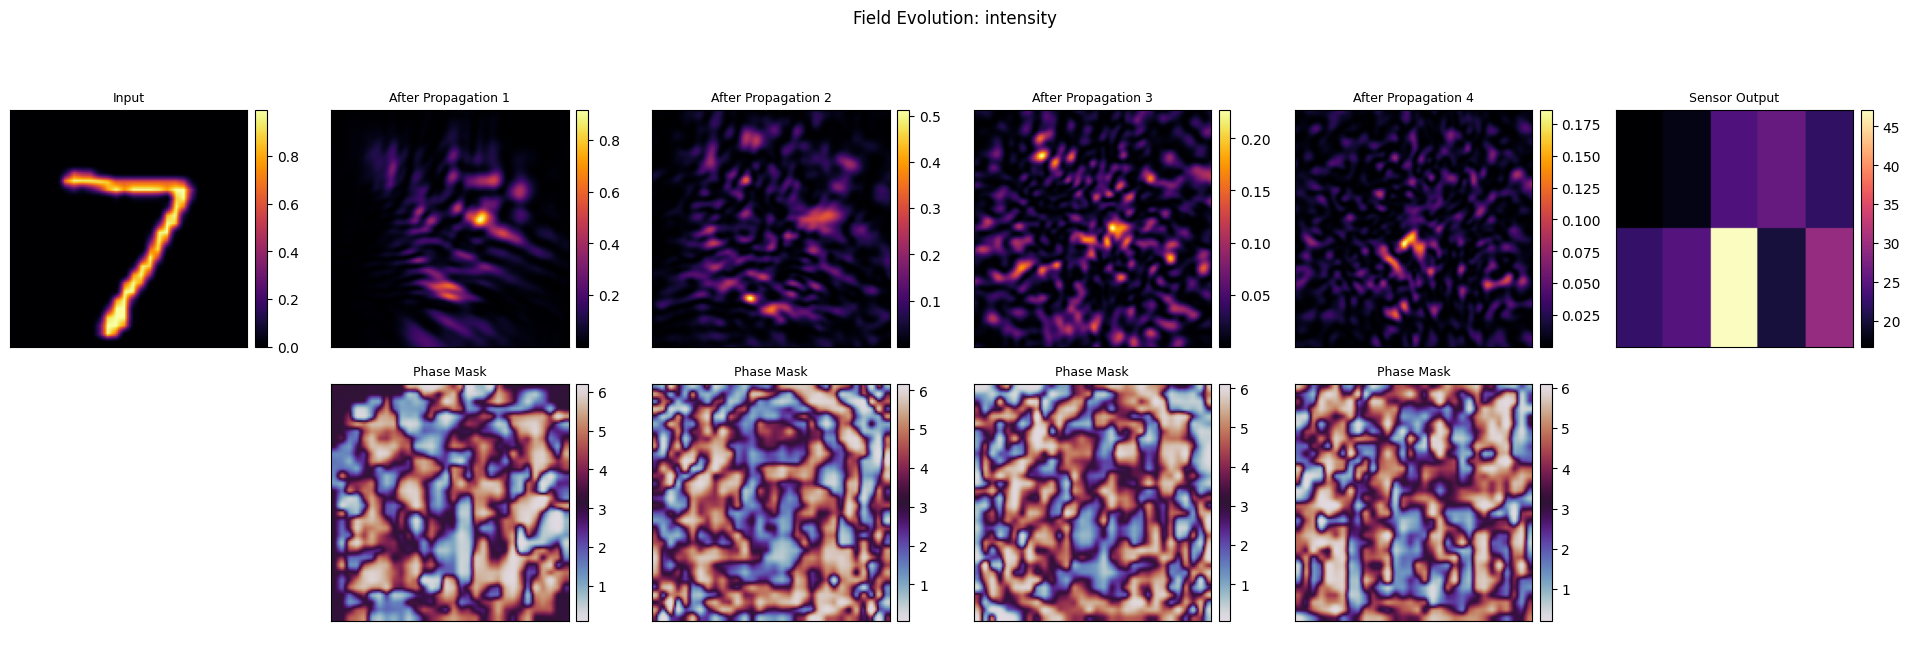

In [16]:
with jax.default_device(selected_device):
    module = build_onn_module(
        phase_params,
        work_grid,
        propagator,
        detector_sensor,
    )
    sample_idx = 0
    test_image = jnp.asarray(x_test[sample_idx], dtype=jnp.float32)
    sample_field = Field(
        data=test_image[None, :, :].astype(jnp.complex64),
        grid=work_grid,
        spectrum=spectrum,
    )

    fig_field, _ = plot_field_evolution(
        module=module,
        field_in=sample_field,
        mode="intensity",
        wavelength_idx=0,
        log_scale=False,
    )
    fig_field.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
fig_field.savefig(FIELD_EVOLUTION_PATH, dpi=160)
print("saved:", FIELD_EVOLUTION_PATH)
